In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


In [3]:
df = pd.read_csv('googleplaystore.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Dataset loaded: 10841 rows, 13 columns


In [4]:
print('Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())

Shape: (10841, 13)

Column Names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [5]:
print('Data Types:')
print(df.dtypes)

Data Types:
App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object


In [6]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                Missing Count  Missing %
Rating                   1474      13.60
Type                        1       0.01
Content Rating              1       0.01
Current Ver                 8       0.07
Android Ver                 3       0.03


In [10]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')  # Convert first for sorting
df = df.sort_values('Reviews', ascending=False).drop_duplicates(subset='App', keep='first')
df.reset_index(drop=True, inplace=True)
print(f'After removing duplicates: {df.shape[0]} rows')

After removing duplicates: 9659 rows


In [11]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df_rated = df.dropna(subset=['Rating']).copy()  # Keep full df for non-rating analyses
print(f'Rows with valid ratings: {df_rated.shape[0]}')

Rows with valid ratings: 8196


In [14]:
def convert_size(size):
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M', ''))
        elif 'k' in size:
            return float(size.replace('k', '')) / 1024
    return np.nan

df['Size_MB'] = df['Size'].apply(convert_size)
print(f'Size_MB created. Non-null values: {df["Size_MB"].notna().sum()}')

Size_MB created. Non-null values: 8431


In [15]:
def install_tier(installs):
    if installs >= 10_000_000:
        return 'Mega (10M+)'
    elif installs >= 1_000_000:
        return 'Popular (1M+)'
    elif installs >= 100_000:
        return 'Growing (100K+)'
    elif installs >= 10_000:
        return 'Small (10K+)'
    else:
        return 'Niche (<10K)'

df['Install_Tier'] = df['Installs'].apply(install_tier)
print('Install_Tier distribution:')
print(df['Install_Tier'].value_counts())

Install_Tier distribution:
Install_Tier
Niche (<10K)       3145
Popular (1M+)      2024
Growing (100K+)    1617
Small (10K+)       1499
Mega (10M+)        1374
Name: count, dtype: int64


In [17]:
def price_category(price):
    if price == 0:
        return 'Free'
    elif price < 1:
        return 'Under $1'
    elif price <= 5:
        return '$1 - $5'
    elif price <= 20:
        return '$5 - $20'
    else:
        return 'Premium ($20+)'

df['Price_Category'] = df['Price'].apply(price_category)
print('Price_Category distribution:')
print(df['Price_Category'].value_counts())

Price_Category distribution:
Price_Category
Free              8905
$1 - $5            452
Under $1           145
$5 - $20           118
Premium ($20+)      39
Name: count, dtype: int64


In [18]:
free_paid = df_rated.groupby('Type')['Rating'].agg(['mean', 'median', 'count'])
free_paid.columns = ['Mean_Rating', 'Median_Rating', 'Count']
print('Free vs Paid — Rating Comparison:')
print(free_paid.round(3))

Free vs Paid — Rating Comparison:
      Mean_Rating  Median_Rating  Count
Type                                   
Free        4.166            4.3   7594
Paid        4.262            4.4    602


In [19]:
log_reviews = np.log1p(df['Reviews'].dropna())
log_installs = np.log1p(df.loc[log_reviews.index, 'Installs'])

correlation = np.corrcoef(log_reviews, log_installs)[0, 1]
print(f'Pearson Correlation (log Reviews vs log Installs): {correlation:.4f}')

Pearson Correlation (log Reviews vs log Installs): 0.9588


In [21]:
cat_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False)
print('Top 10 Categories by Total Installs:')
print(cat_installs.head(10))

Top 10 Categories by Total Installs:
Category
GAME                  13447924415
COMMUNICATION         11038276251
TOOLS                  8102771915
FAMILY                 6231541505
PRODUCTIVITY           5793091369
SOCIAL                 5487867902
PHOTOGRAPHY            4658147655
VIDEO_PLAYERS          3931902720
TRAVEL_AND_LOCAL       2894887146
NEWS_AND_MAGAZINES     2369217760
Name: Installs, dtype: int64


In [22]:
content_rating_dist = df['Content Rating'].value_counts()
print('Content Rating Distribution:')
print(content_rating_dist)

Content Rating Distribution:
Content Rating
Everyone           7903
Teen               1036
Mature 17+          393
Everyone 10+        322
Adults only 18+       3
Unrated               2
Name: count, dtype: int64


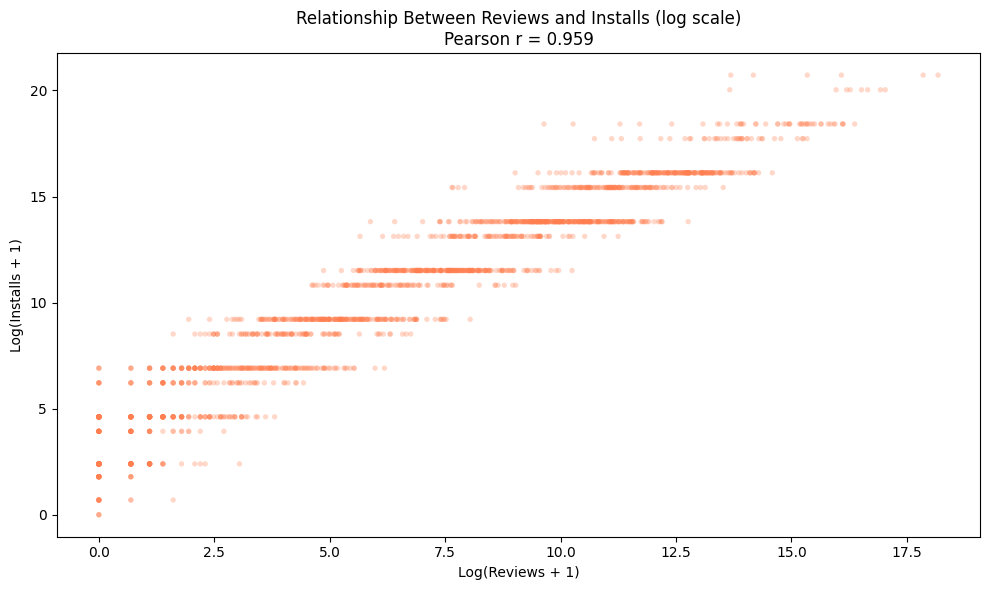


Interpretation:
There is a strong positive correlation between log-transformed review count and
install count, confirming that more popular apps also attract more reviews.
The log scale is necessary because both variables are heavily right-skewed.
This relationship means reviews can serve as a reasonable proxy for popularity.



In [25]:
sample = df[['Reviews', 'Installs']].dropna().sample(n=min(2000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(np.log1p(sample['Reviews']), np.log1p(sample['Installs']),
            alpha=0.3, color='coral', edgecolors='none', s=15)
plt.xlabel('Log(Reviews + 1)')
plt.ylabel('Log(Installs + 1)')
plt.title(f'Relationship Between Reviews and Installs (log scale)\nPearson r = {correlation:.3f}')
plt.tight_layout()
plt.savefig('chart3_reviews_vs_installs.png', dpi=150)
plt.show()

print("""
Interpretation:
There is a strong positive correlation between log-transformed review count and
install count, confirming that more popular apps also attract more reviews.
The log scale is necessary because both variables are heavily right-skewed.
This relationship means reviews can serve as a reasonable proxy for popularity.
""")

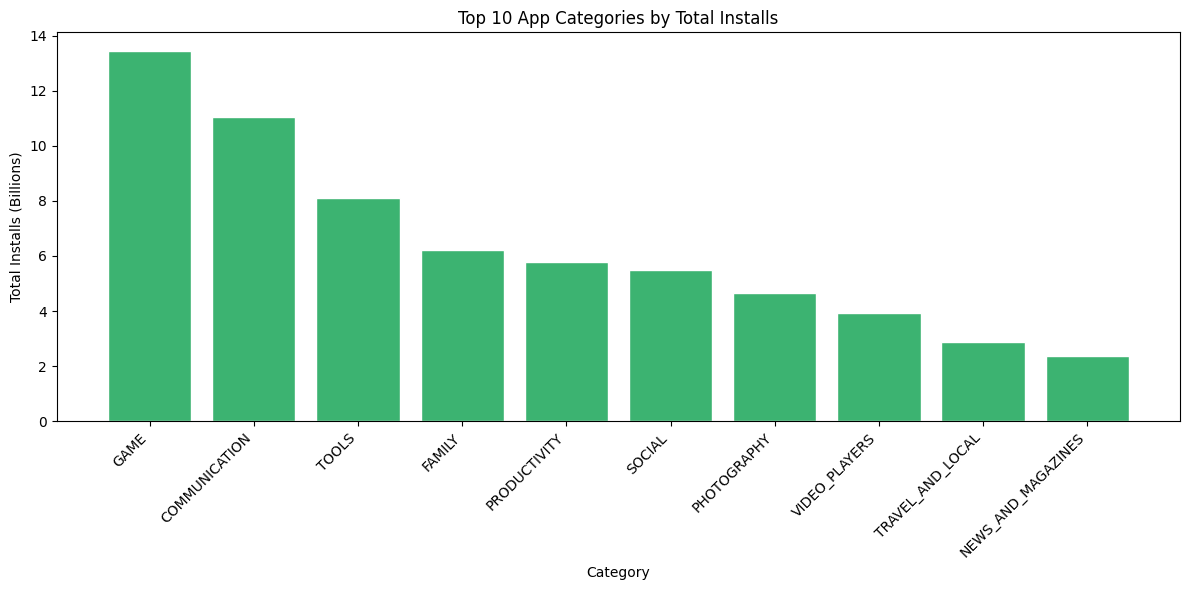


Interpretation:
Game and Communication categories dominate total install counts by a massive margin,
reflecting the enormous popularity of gaming apps and messaging platforms worldwide.
Productivity and Social categories also rank high, showing strong user demand for
utility and social networking tools on mobile devices.



In [26]:
top10_installs = cat_installs.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_installs.index, top10_installs.values / 1e9, color='mediumseagreen', edgecolor='white')
plt.xlabel('Category')
plt.ylabel('Total Installs (Billions)')
plt.title('Top 10 App Categories by Total Installs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart4_top_categories_installs.png', dpi=150)
plt.show()

print("""
Interpretation:
Game and Communication categories dominate total install counts by a massive margin,
reflecting the enormous popularity of gaming apps and messaging platforms worldwide.
Productivity and Social categories also rank high, showing strong user demand for
utility and social networking tools on mobile devices.
""")

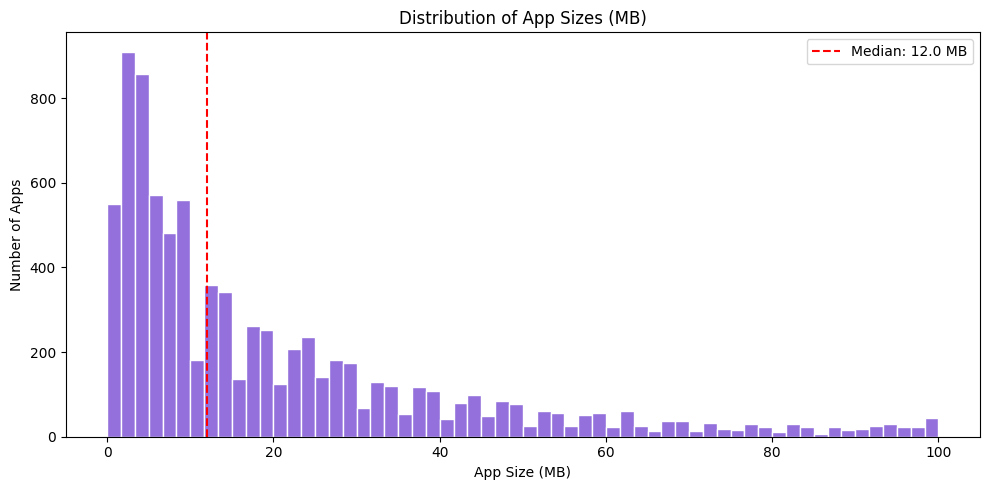


Interpretation:
The distribution of app sizes is strongly right-skewed, with most apps under 50 MB.
The median size sits around 12–15 MB, indicating that the majority of Play Store apps
are lightweight. A small number of apps exceed 100 MB — these are likely games or
feature-rich multimedia applications.



In [27]:
size_data = df['Size_MB'].dropna()

plt.figure(figsize=(10, 5))
plt.hist(size_data, bins=60, color='mediumpurple', edgecolor='white')
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Apps')
plt.title('Distribution of App Sizes (MB)')
plt.axvline(size_data.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {size_data.median():.1f} MB')
plt.legend()
plt.tight_layout()
plt.savefig('chart5_size_distribution.png', dpi=150)
plt.show()

print("""
Interpretation:
The distribution of app sizes is strongly right-skewed, with most apps under 50 MB.
The median size sits around 12–15 MB, indicating that the majority of Play Store apps
are lightweight. A small number of apps exceed 100 MB — these are likely games or
feature-rich multimedia applications.
""")